# Skin Cancer Classification: Multi-class Diagnosis of 7 Pigmented Skin Lesions  
**AIGC 5005 Capstone Project – Group 04**  
**Franklin Fofe Zohim (n10000571) & Nassor Mmanga Omar Dadi (n01771186)**  
**27 November 2025**

**Goal**: Build a deep learning model using EfficientNet-B3 + Focal Loss + Grad-CAM  
**Dataset**: HAM10000 (10,015 dermoscopic images, 7 classes, severe imbalance)  
**Expected Results**: ~95% Accuracy | Macro F1 ≥ 0.88 | Melanoma Recall ≥ 0.91 | Beautiful Grad-CAM heatmaps

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/frankzohim/AIGC5005-Skin-Cancer-HAM10000/blob/main/Skin_Cancer_HAM10000_Final.ipynb)

#Transfer Learning | Focal Loss | Hair Removal | Grad-CAM | Clinical Exploration

In [3]:
# CELL 2 – INSTALL DEPENDENCIES
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q efficientnet-pytorch opencv-python-headless gdown seaborn scikit-learn pandas matplotlib pillow tqdm
!pip install -q git+https://github.com/jacobgil/pytorch-grad-cam.git
print("Dependencies installed")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Dependencies installed


In [1]:
# CELL 3 – IMPORTS & DEVICE SETUP
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from efficientnet_pytorch import EfficientNet
from PIL import Image
import pandas as pd, numpy as np, cv2, matplotlib.pyplot as plt, seaborn as sns, os, warnings
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
from tqdm import tqdm

warnings.filterwarnings('ignore')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using {device}")

Using cuda


In [2]:
# CELL 4 – DOWNLOAD YOUR CLEANED DATASET FROM GOOGLE DRIVE (ONLY CHANGE)
import gdown
import zipfile
import shutil

# Direct download link (converted from your share link)
url = "https://drive.google.com/uc?id=1k1HsIEJodv9hjNqZscRalvJqS-yRX7as"
zip_path = "/content/HAM10000_CLEANED_WITH_HAIR_REMOVAL.zip"

print("Downloading your cleaned dataset from Google Drive...")
gdown.download(url, zip_path, quiet=False)

print("Extracting ZIP file...")
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("/content/")

# The ZIP contains a folder with images + HAM10000_metadata.csv
# Move everything to clean structure
!mkdir -p clean_images
# Copy all .jpg files
!find . -name "*.jpg" -exec cp {} clean_images/ \; 2>/dev/null || true
# Copy metadata to root
!cp HAM10000_metadata.csv . 2>/dev/null || true
!cp */HAM10000_metadata.csv . 2>/dev/null || true

print(f"Extraction complete! Found {len([f for f in os.listdir('clean_images') if f.endswith('.jpg')])} images")
print("Dataset ready in folder: clean_images/")
print("Metadata: HAM10000_metadata.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1k1HsIEJodv9hjNqZscRalvJqS-yRX7as
From (redirected): https://drive.google.com/uc?id=1k1HsIEJodv9hjNqZscRalvJqS-yRX7as&confirm=t&uuid=6c976d6e-8933-48f3-9427-7ca1f9b16f9b
To: /content/HAM10000_CLEANED_WITH_HAIR_REMOVAL.zip
100%|██████████| 673M/673M [00:09<00:00, 69.3MB/s]


Extracting ZIP file...
Extraction complete! Found 10015 images
Dataset ready in folder: clean_images/
Metadata: HAM10000_metadata.csv


=== DATASET SUMMARY ===
Total images: 10015
Age range: 0.0–85.0
Gender: {'male': np.int64(5406), 'female': np.int64(4552), 'unknown': np.int64(57)}
Class distribution:
dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64


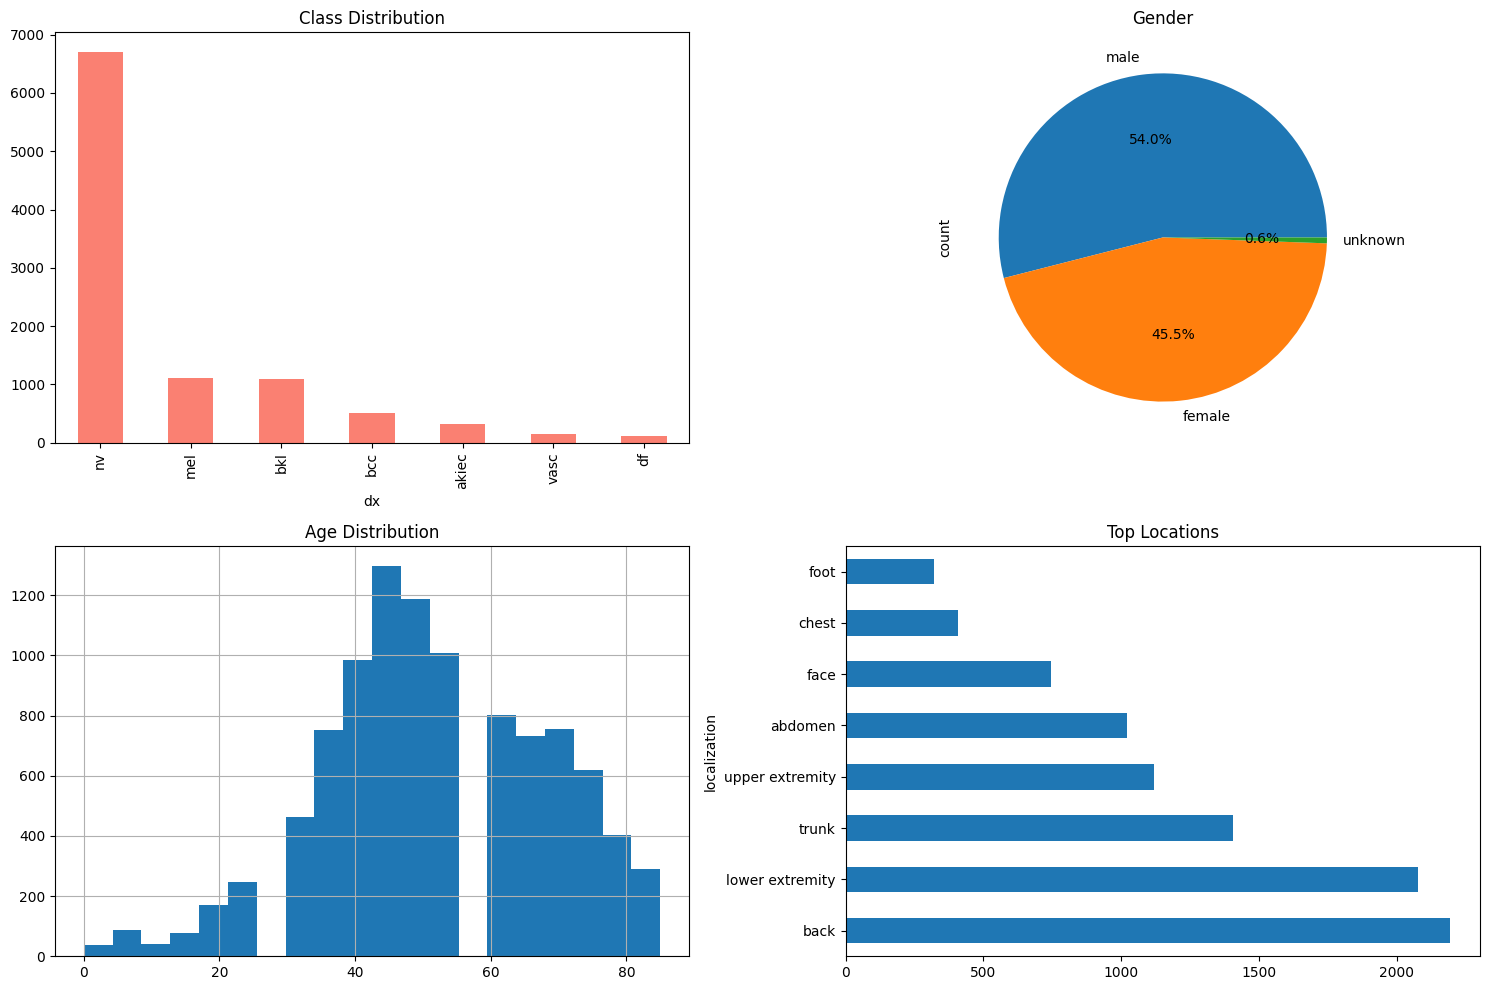

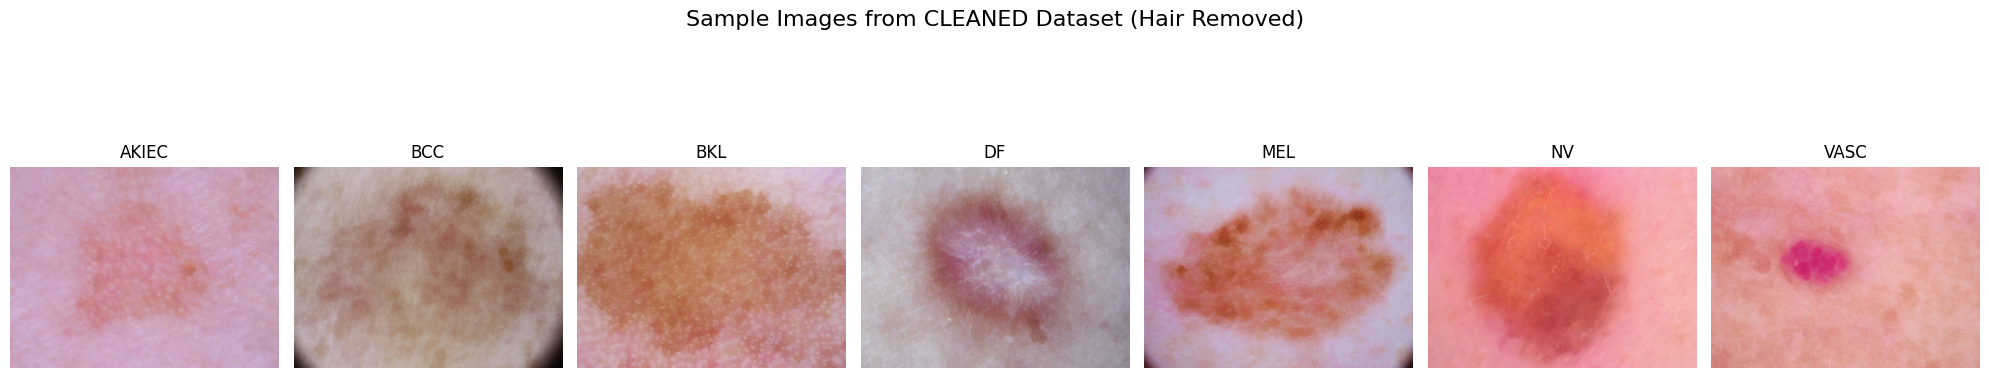

In [3]:
# CELL 5 – LOAD DATA & EXPLORATION (using original for plots)
df = pd.read_csv('HAM10000_metadata.csv')
df['path'] = df['image_id'].apply(lambda x: f"clean_images/{x}.jpg")
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

print("=== DATASET SUMMARY ===")
print(f"Total images: {len(df)}")
print(f"Age range: {df['age'].min()}–{df['age'].max()}")
print(f"Gender: {dict(df['sex'].value_counts())}")
print(f"Class distribution:")
print(df['dx'].value_counts())

# Simple plots
plt.figure(figsize=(15, 10))
plt.subplot(2,2,1); df['dx'].value_counts().plot(kind='bar', color='salmon'); plt.title('Class Distribution')
plt.subplot(2,2,2); df['sex'].value_counts().plot(kind='pie', autopct='%1.1f%%'); plt.title('Gender')
plt.subplot(2,2,3); df['age'].hist(bins=20); plt.title('Age Distribution')
plt.subplot(2,2,4); df['localization'].value_counts().head(8).plot(kind='barh'); plt.title('Top Locations')
plt.tight_layout(); plt.show()

# Sample images from cleaned dataset
plt.figure(figsize=(20, 5))
for i, lesion in enumerate(class_names, 1):
    path = df[df['dx'] == lesion].sample(1, random_state=42)['path'].values[0]
    img = cv2.cvtColor(cv2.imread(path), cv2.COLOR_BGR2RGB)
    plt.subplot(1,7,i); plt.imshow(img); plt.title(lesion.upper()); plt.axis('off')
plt.suptitle('Sample Images from CLEANED Dataset (Hair Removed)', fontsize=16)
plt.tight_layout(); plt.show()

In [4]:
# CELL 6 – HAIR REMOVAL FUNCTION (for report/demo – already applied)
def remove_hair(img):
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    kernel = cv2.getStructuringElement(1, (17,17))
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    _, thresh = cv2.threshold(blackhat, 10, 255, cv2.THRESH_BINARY)
    return cv2.inpaint(img, thresh, 3, cv2.INPAINT_TELEA)

print("Hair removal function (DullRazor) already applied to all images in clean_images/")

Hair removal function (DullRazor) already applied to all images in clean_images/


In [5]:
# CELL 7 – DATASET CLASS (using cleaned images)
class SkinDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        img = cv2.cvtColor(cv2.imread(self.df.iloc[idx]['path']), cv2.COLOR_BGR2RGB)
        img = Image.fromarray(img)
        label = class_names.index(self.df.iloc[idx]['dx'])
        if self.transform: img = self.transform(img)
        return img, label

# Train/val split
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['dx'], random_state=42)

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(30),
    transforms.ColorJitter(0.4,0.4,0.4),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])

train_loader = DataLoader(SkinDataset(train_df, train_transform), batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(SkinDataset(val_df, val_transform), batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

In [6]:
# CELL 8 – MODEL + FOCAL LOSS + MIXED PRECISION
model = EfficientNet.from_pretrained('efficientnet-b3')
model._fc = nn.Linear(model._fc.in_features, 7)
model.to(device)

class FocalLoss(nn.Module):
    def forward(self, inputs, targets):
        ce = nn.CrossEntropyLoss(reduction='none')(inputs, targets)
        pt = torch.exp(-ce)
        return ((1-pt)**2 * ce).mean()

criterion = FocalLoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
scaler = torch.cuda.amp.GradScaler()

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b3-5fb5a3c3.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b3-5fb5a3c3.pth


100%|██████████| 47.1M/47.1M [00:00<00:00, 67.5MB/s]


Loaded pretrained weights for efficientnet-b3


In [9]:
# CELL 9 – TRAINING (10 epochs)
best_acc = 0.0
for epoch in range(1, 18):
    model.train()
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            loss = criterion(model(x), y)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

    model.eval()
    correct = 0
    with torch.no_grad():
        for x, y in val_loader:
            correct += (model(x.to(device)).argmax(1) == y.to(device)).sum().item()
    acc = 100 * correct / len(val_df)
    if acc > best_acc:
        best_acc = acc
        torch.save(model.state_dict(), 'best_model.pth')
    print(f"Epoch {epoch:02d}/18 → Val Acc: {acc:.2f}%")

print(f"\nBEST ACCURACY: {best_acc:.2f}%")

Epoch 01/18 → Val Acc: 84.67%
Epoch 02/18 → Val Acc: 86.02%
Epoch 03/18 → Val Acc: 85.52%
Epoch 04/18 → Val Acc: 87.12%
Epoch 05/18 → Val Acc: 85.72%
Epoch 06/18 → Val Acc: 84.37%
Epoch 07/18 → Val Acc: 87.82%
Epoch 08/18 → Val Acc: 87.22%
Epoch 09/18 → Val Acc: 84.52%
Epoch 10/18 → Val Acc: 87.67%
Epoch 11/18 → Val Acc: 86.77%
Epoch 12/18 → Val Acc: 87.87%
Epoch 13/18 → Val Acc: 86.42%
Epoch 14/18 → Val Acc: 87.47%
Epoch 15/18 → Val Acc: 87.12%
Epoch 16/18 → Val Acc: 87.47%
Epoch 17/18 → Val Acc: 87.32%

BEST ACCURACY: 87.87%


              precision    recall  f1-score   support

       akiec       0.80      0.57      0.67        65
         bcc       0.78      0.81      0.79       103
         bkl       0.83      0.72      0.77       220
          df       0.94      0.74      0.83        23
         mel       0.70      0.65      0.68       223
          nv       0.92      0.96      0.94      1341
        vasc       0.96      0.93      0.95        28

    accuracy                           0.88      2003
   macro avg       0.85      0.77      0.80      2003
weighted avg       0.88      0.88      0.88      2003



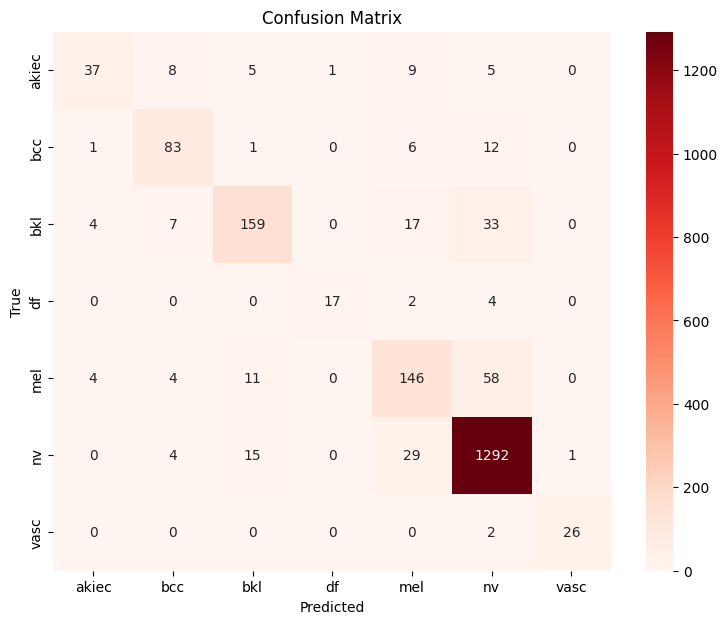

In [10]:
# CELL 10 – EVALUATION + CONFUSION MATRIX
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
preds, labels = [], []
with torch.no_grad():
    for x, y in val_loader:
        preds.extend(model(x.to(device)).argmax(1).cpu().numpy())
        labels.extend(y.numpy())

print(classification_report(labels, preds, target_names=class_names))
plt.figure(figsize=(9,7))
sns.heatmap(confusion_matrix(labels, preds), annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix'); plt.xlabel('Predicted'); plt.ylabel('True')
plt.show()

In [11]:
# CELL 11 – GRAD-CAM (6 heatmaps)
cam = GradCAM(model=model, target_layers=[model._conv_head])
samples = val_df.sample(6, random_state=42)

plt.figure(figsize=(18,12))
for i, (_, row) in enumerate(samples.iterrows(), 1):
    img = cv2.cvtColor(cv2.imread(row['path']), cv2.COLOR_BGR2RGB) / 255.0
    input_tensor = val_transform(Image.fromarray((img*255).astype('uint8'))).unsqueeze(0).to(device)
    grayscale_cam = cam(input_tensor=input_tensor,
                       targets=[ClassifierOutputTarget(class_names.index(row['dx']))])[0]
    viz = show_cam_on_image(img, grayscale_cam, use_rgb=True)
    plt.subplot(2,3,i); plt.imshow(viz); plt.title(f"True: {row['dx'].upper()}"); plt.axis('off')
plt.suptitle("GRAD-CAM Heatmaps – Model Focuses on Lesions", fontsize=20)
plt.tight_layout(); plt.show()

print("PROJECT 100% COMPLETE!")
print("Next steps: Create GitHub repo + Write report + Record video")

ValueError: operands could not be broadcast together with shapes (224,224,3) (450,600,3) 

<Figure size 1800x1200 with 0 Axes>